# Cell 1 - Markdown
"""
# 02 Exploratory Data Analysis and Feature Engineering

## Student Performance Prediction Using Machine Learning

This notebook analyzes the cleaned student performance dataset.

Main tasks:
- Load cleaned data
- Analyze numerical and categorical features
- Analyze Pass/Fail distribution
- Create statistical tables
- Create visualizations
- Study correlations
- Save report-ready figures and tables
"""

In [1]:
# Cell 2 - Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Cell 3 - Define Paths

PROJECT_ROOT = Path("..")

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "StudentPerformanceFactors_cleaned.csv"

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data path:", PROCESSED_DATA_PATH)
print("Figures directory:", FIGURES_DIR)
print("Tables directory:", TABLES_DIR)

Processed data path: ..\data\processed\StudentPerformanceFactors_cleaned.csv
Figures directory: ..\outputs\figures
Tables directory: ..\outputs\tables


In [3]:
# Cell 4 - Load Cleaned Dataset

df = pd.read_csv(PROCESSED_DATA_PATH)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance_Label,Pass_Fail
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67,Pass,1
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61,Pass,1
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Pass,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Pass,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70,Pass,1


In [4]:
# Cell 5 - Dataset Overview

print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn Names:")
for col in df.columns:
    print("-", col)

Dataset Shape:
Rows: 6607
Columns: 22

Column Names:
- Hours_Studied
- Attendance
- Parental_Involvement
- Access_to_Resources
- Extracurricular_Activities
- Sleep_Hours
- Previous_Scores
- Motivation_Level
- Internet_Access
- Tutoring_Sessions
- Family_Income
- Teacher_Quality
- School_Type
- Peer_Influence
- Physical_Activity
- Learning_Disabilities
- Parental_Education_Level
- Distance_from_Home
- Gender
- Exam_Score
- Performance_Label
- Pass_Fail


In [5]:
# Cell 6 - Check Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
# Cell 7 - Separate Numerical and Categorical Columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score', 'Pass_Fail']

Categorical Columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Performance_Label']


In [7]:
# Cell 8 - Remove Target Columns From Feature Lists

target_cols = ["Exam_Score", "Performance_Label", "Pass_Fail"]

numerical_features = [col for col in numerical_cols if col not in target_cols]
categorical_features = [col for col in categorical_cols if col not in target_cols]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical Features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [8]:
# Cell 9 - Statistical Summary Table

stats_table = df[numerical_features + ["Exam_Score"]].agg(
    ["mean", "median", "std", "min", "max"]
).T

stats_table = stats_table.rename(columns={
    "mean": "Mean",
    "median": "Median",
    "std": "Standard Deviation",
    "min": "Minimum",
    "max": "Maximum"
})

stats_table = stats_table.round(3)

stats_table

,Mean,Median,Standard Deviation,Minimum,Maximum
Hours_Studied,19.975,20.0,5.991,1.0,44.0
Attendance,79.977,80.0,11.547,60.0,100.0
Sleep_Hours,7.029,7.0,1.468,4.0,10.0
Previous_Scores,75.071,75.0,14.400,50.0,100.0
Tutoring_Sessions,1.494,1.0,1.231,0.0,8.0
Physical_Activity,2.968,3.0,1.031,0.0,6.0
Exam_Score,67.236,67.0,3.889,55.0,100.0


In [9]:
# Cell 10 - Save Statistical Summary

stats_table.to_csv(TABLES_DIR / "dataset_statistics.csv")

print("Dataset statistics table saved successfully.")
print("Saved to:", TABLES_DIR / "dataset_statistics.csv")

Dataset statistics table saved successfully.
Saved to: ..\outputs\tables\dataset_statistics.csv


In [10]:
# Cell 11 - Target Distribution Table

class_counts = df["Performance_Label"].value_counts()
class_percentages = df["Performance_Label"].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values,
    "Percentage (%)": class_percentages.round(2).values
})

class_distribution

,Class,Count,Percentage (%)
0,Pass,6539,98.97
1,Fail,68,1.03


In [11]:
# Cell 12 - Save Target Distribution Table

class_distribution.to_csv(TABLES_DIR / "class_distribution.csv", index=False)

print("Class distribution table saved successfully.")
print("Saved to:", TABLES_DIR / "class_distribution.csv")

Class distribution table saved successfully.
Saved to: ..\outputs\tables\class_distribution.csv


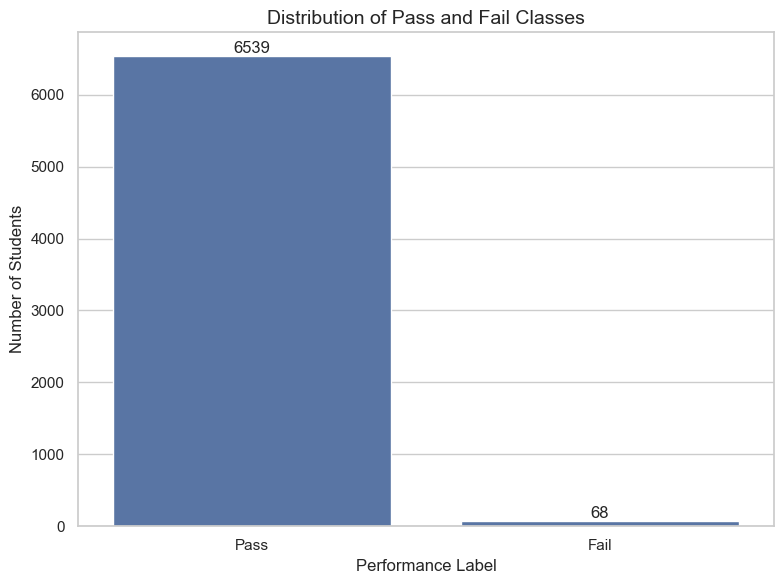

In [12]:
# Cell 13 - Plot Target Distribution

plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x="Performance_Label", order=["Pass", "Fail"])

plt.title("Distribution of Pass and Fail Classes", fontsize=14)
plt.xlabel("Performance Label")
plt.ylabel("Number of Students")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

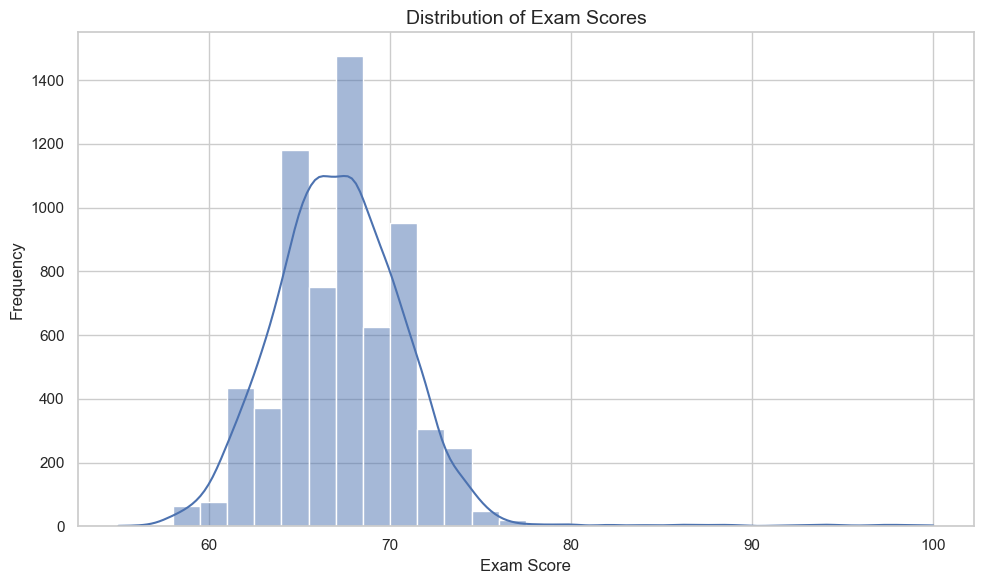

In [13]:
# Cell 14 - Exam Score Distribution

plt.figure(figsize=(10, 6))

sns.histplot(df["Exam_Score"], bins=30, kde=True)

plt.title("Distribution of Exam Scores", fontsize=14)
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "exam_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

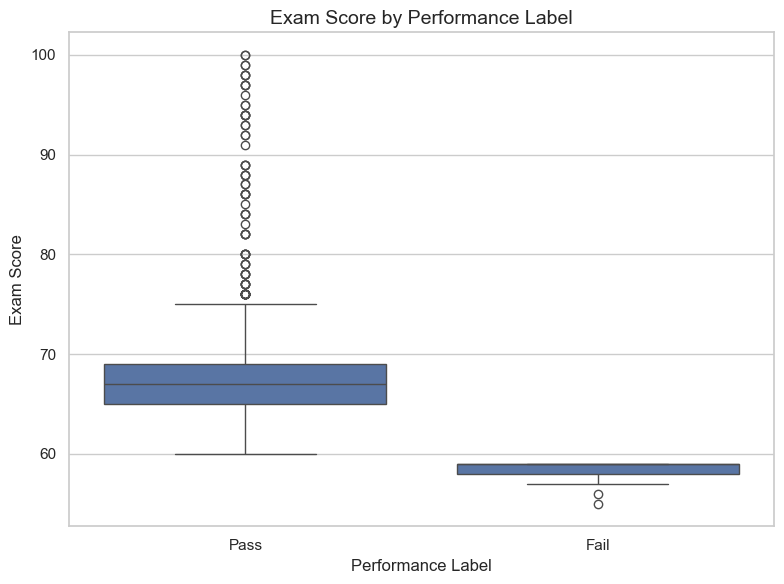

In [14]:
# Cell 15 - Boxplot Exam Score by Label

plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x="Performance_Label", y="Exam_Score", order=["Pass", "Fail"])

plt.title("Exam Score by Performance Label", fontsize=14)
plt.xlabel("Performance Label")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "exam_score_by_performance_label.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Cell 16 - Correlation With Exam Score

corr_with_exam = df[numerical_features + ["Exam_Score"]].corr(numeric_only=True)["Exam_Score"].sort_values(ascending=False)

corr_table = corr_with_exam.drop("Exam_Score").reset_index()
corr_table.columns = ["Feature", "Correlation with Exam_Score"]
corr_table["Correlation with Exam_Score"] = corr_table["Correlation with Exam_Score"].round(3)

corr_table

,Feature,Correlation with Exam_Score
0,Attendance,0.581
1,Hours_Studied,0.446
2,Previous_Scores,0.175
3,Tutoring_Sessions,0.156
4,Physical_Activity,0.028
5,Sleep_Hours,-0.017


In [16]:
# Cell 17 - Save Correlation Table

corr_table.to_csv(TABLES_DIR / "correlation_with_exam_score.csv", index=False)

print("Correlation table saved successfully.")
print("Saved to:", TABLES_DIR / "correlation_with_exam_score.csv")

Correlation table saved successfully.
Saved to: ..\outputs\tables\correlation_with_exam_score.csv


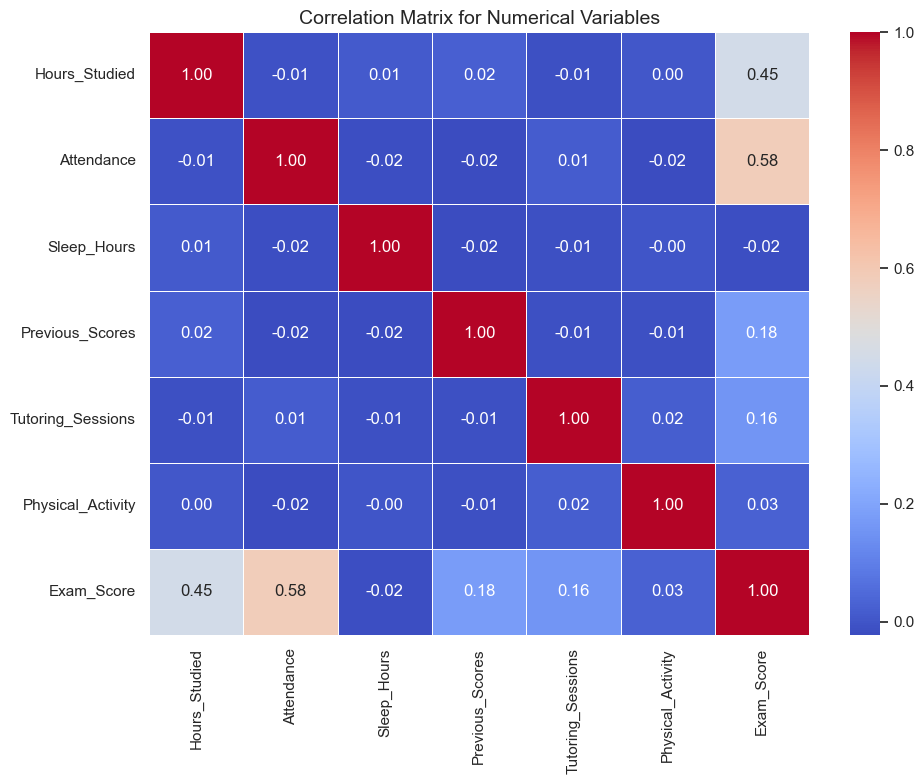

In [17]:
# Cell 18 - Correlation Matrix Plot

plt.figure(figsize=(10, 8))

corr_matrix = df[numerical_features + ["Exam_Score"]].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix for Numerical Variables", fontsize=14)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

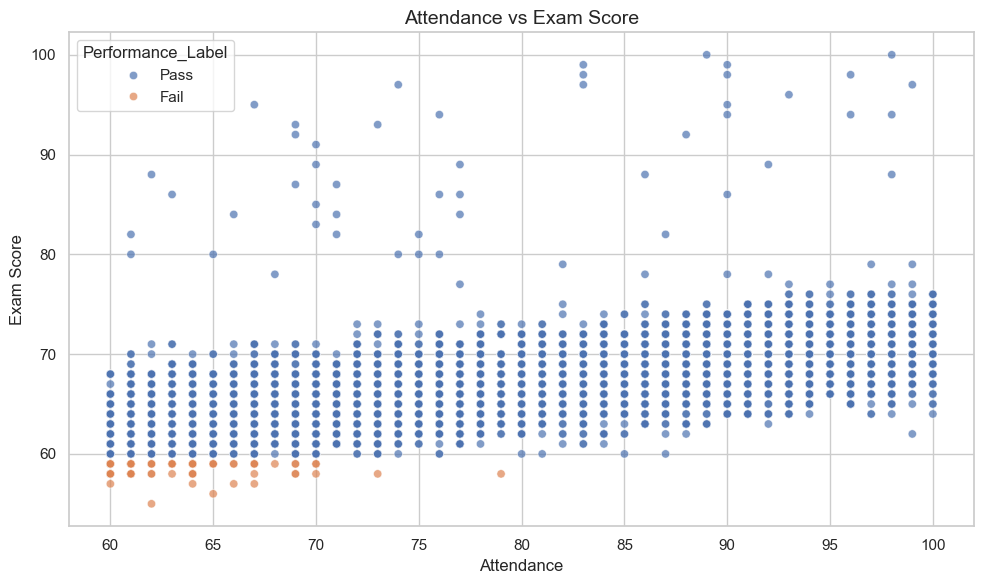

In [18]:
# Cell 19 - Attendance vs Exam Score

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Attendance", y="Exam_Score", hue="Performance_Label", alpha=0.7)

plt.title("Attendance vs Exam Score", fontsize=14)
plt.xlabel("Attendance")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "attendance_vs_exam_score.png", dpi=300, bbox_inches="tight")
plt.show()

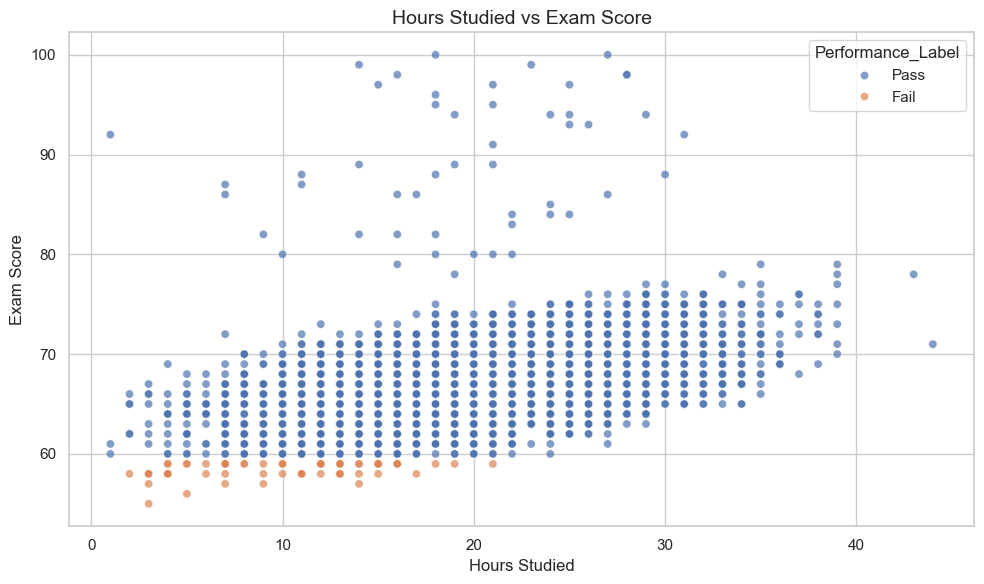

In [19]:
# Cell 20 - Hours Studied vs Exam Score

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score", hue="Performance_Label", alpha=0.7)

plt.title("Hours Studied vs Exam Score", fontsize=14)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "hours_studied_vs_exam_score.png", dpi=300, bbox_inches="tight")
plt.show()

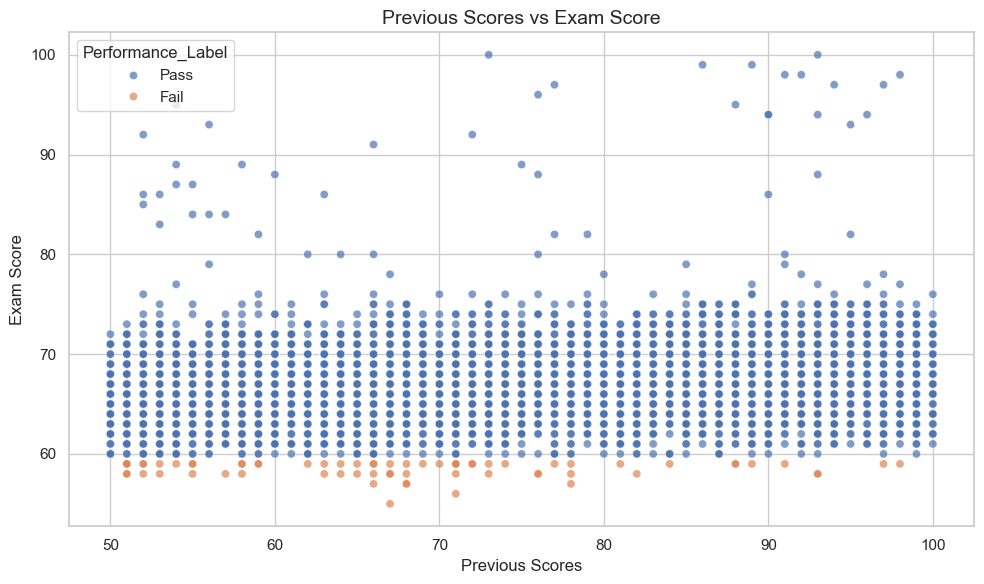

In [20]:
# Cell 21 - Previous Scores vs Exam Score

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Previous_Scores", y="Exam_Score", hue="Performance_Label", alpha=0.7)

plt.title("Previous Scores vs Exam Score", fontsize=14)
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "previous_scores_vs_exam_score.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Cell 22 - Display Unique Values for Categorical Features

for col in categorical_features:
    print(f"\n{col}:")
    print(df[col].value_counts())


Parental_Involvement:
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources:
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities:
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level:
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access:
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income:
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality:
Teacher_Quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64

School_Type:
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence:
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities:
Learning_Disabilities
No     5912
Yes     695
Name: 

In [22]:
# Cell 23 - Categorical Feature Summary

categorical_summary_list = []

for col in categorical_features:
    value_counts = df[col].value_counts()

    categorical_summary_list.append({
        "Feature": col,
        "Number of Categories": df[col].nunique(),
        "Most Frequent Category": value_counts.index[0],
        "Most Frequent Count": value_counts.iloc[0],
        "Most Frequent Percentage (%)": round((value_counts.iloc[0] / len(df)) * 100, 2)
    })

categorical_summary_df = pd.DataFrame(categorical_summary_list)

categorical_summary_df

,Feature,Number of Categories,Most Frequent Category,Most Frequent Count,Most Frequent Percentage (%)
0,Parental_Involvement,3,Medium,3362,50.89
1,Access_to_Resources,3,Medium,3319,50.23
2,Extracurricular_Activities,2,Yes,3938,59.60
3,Motivation_Level,3,Medium,3351,50.72
4,Internet_Access,2,Yes,6108,92.45
5,Family_Income,3,Low,2672,40.44
6,Teacher_Quality,3,Medium,4003,60.59
7,School_Type,2,Public,4598,69.59
8,Peer_Influence,3,Positive,2638,39.93
9,Learning_Disabilities,2,No,5912,89.48


In [23]:
# Cell 24 - Save Categorical Feature Summary

categorical_summary_path = TABLES_DIR / "categorical_feature_summary.csv"

categorical_summary_df.to_csv(categorical_summary_path, index=False)

print("Categorical feature summary saved successfully.")
print("Saved to:", categorical_summary_path)

Categorical feature summary saved successfully.
Saved to: ..\outputs\tables\categorical_feature_summary.csv


In [24]:
# Cell 25 - Function to Plot Categorical Features

def plot_categorical_distribution(column_name):
    plt.figure(figsize=(10, 6))

    ax = sns.countplot(
        data=df,
        x=column_name,
        hue="Performance_Label"
    )

    plt.title(f"{column_name} by Performance Label", fontsize=14)
    plt.xlabel(column_name)
    plt.ylabel("Number of Students")
    plt.xticks(rotation=30)

    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()

    file_name = f"{column_name.lower()}_by_performance_label.png"
    plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()

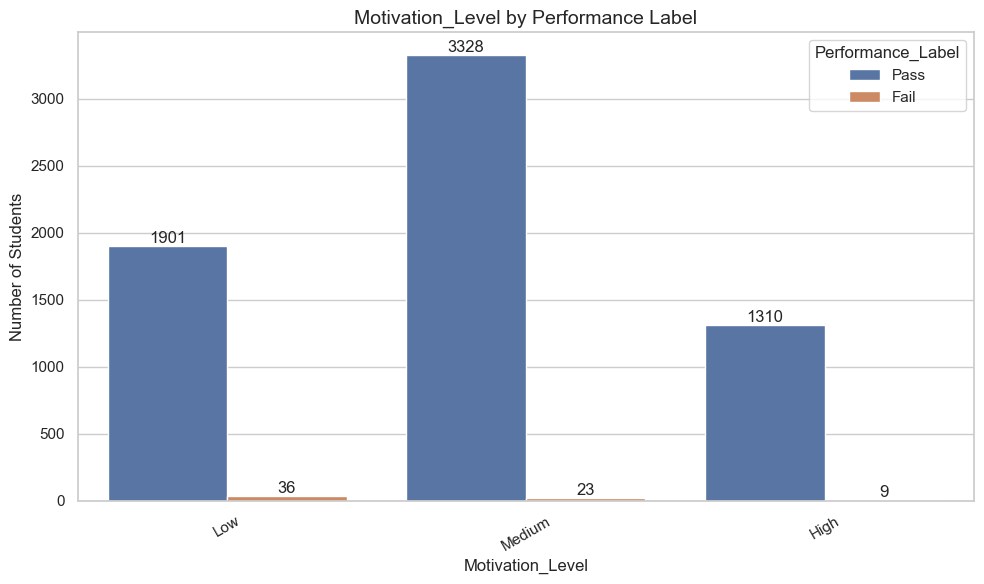

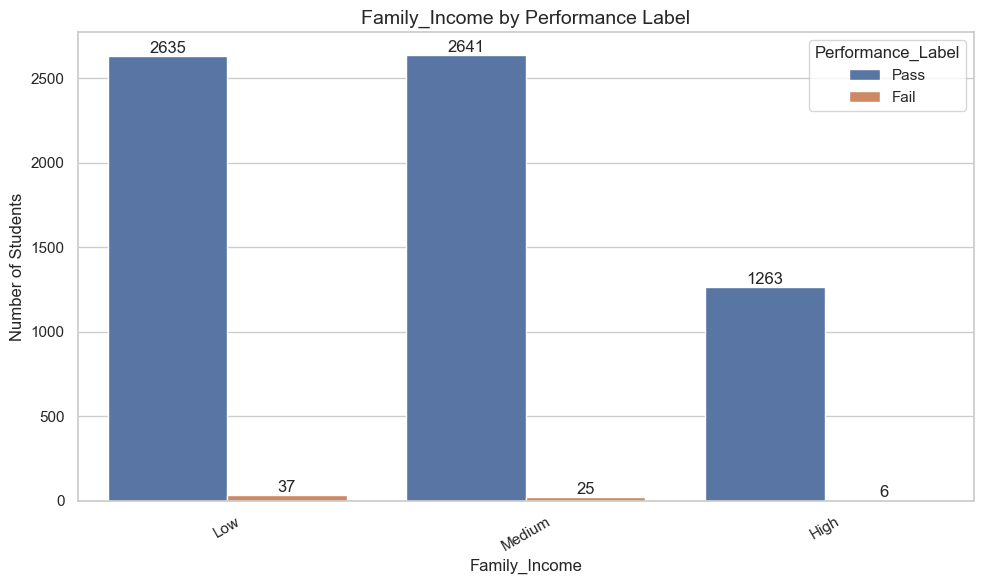

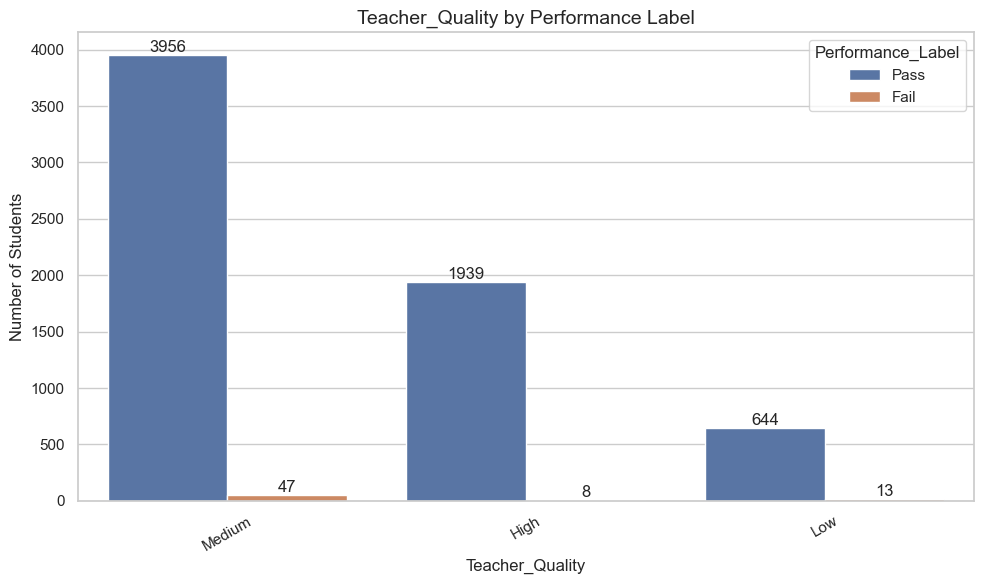

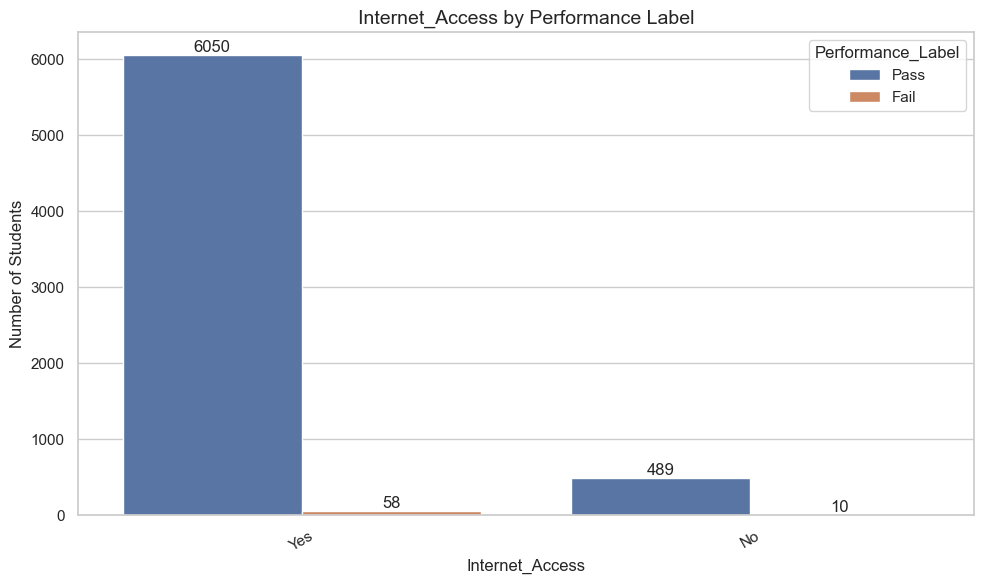

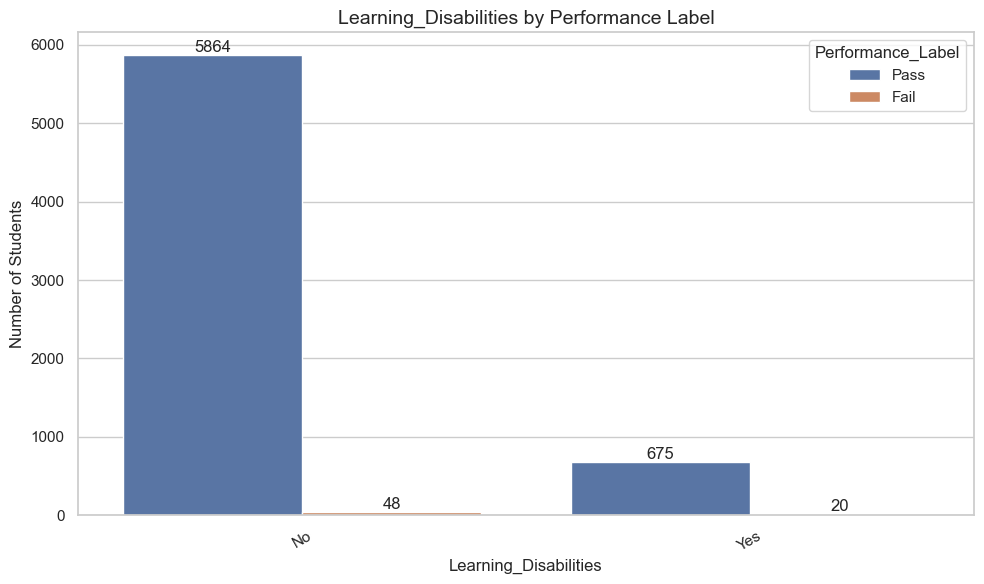

In [25]:
# Cell 26 - Important Categorical Feature Plots

important_categorical_features = [
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
    "Internet_Access",
    "Learning_Disabilities"
]

for feature in important_categorical_features:
    if feature in df.columns:
        plot_categorical_distribution(feature)

In [26]:
# Cell 27 - Feature Type Summary

feature_summary = pd.DataFrame({
    "Feature": numerical_features + categorical_features,
    "Type": ["Numerical"] * len(numerical_features) + ["Categorical"] * len(categorical_features)
})

feature_summary

,Feature,Type
0,Hours_Studied,Numerical
1,Attendance,Numerical
2,Sleep_Hours,Numerical
3,Previous_Scores,Numerical
4,Tutoring_Sessions,Numerical
5,Physical_Activity,Numerical
6,Parental_Involvement,Categorical
7,Access_to_Resources,Categorical
8,Extracurricular_Activities,Categorical
9,Motivation_Level,Categorical


In [27]:
# Cell 28 - Save Feature Type Summary

feature_summary.to_csv(TABLES_DIR / "feature_type_summary.csv", index=False)

print("Feature type summary saved successfully.")
print("Saved to:", TABLES_DIR / "feature_type_summary.csv")

Feature type summary saved successfully.
Saved to: ..\outputs\tables\feature_type_summary.csv


In [28]:
# Cell 29 - Save EDA Summary Text

eda_summary_path = TABLES_DIR / "eda_summary.txt"

eda_summary_text = f"""
EDA Summary

Dataset shape:
Rows: {df.shape[0]}
Columns: {df.shape[1]}

Numerical features:
{numerical_features}

Categorical features:
{categorical_features}

Target distribution:
{df["Performance_Label"].value_counts().to_string()}

Target percentage:
{(df["Performance_Label"].value_counts(normalize=True) * 100).round(2).to_string()}

Main observations:
1. The dataset contains academic, behavioral, social, and environmental factors.
2. The Pass/Fail target is highly imbalanced.
3. Accuracy alone is not enough for model evaluation.
4. Attendance, Hours_Studied, and Previous_Scores show important relationships with Exam_Score.
5. Exam_Score will be excluded from model training to prevent data leakage.
"""

with open(eda_summary_path, "w", encoding="utf-8") as file:
    file.write(eda_summary_text)

print("EDA summary saved successfully.")
print("Saved to:", eda_summary_path)

EDA summary saved successfully.
Saved to: ..\outputs\tables\eda_summary.txt


In [29]:
# Cell 30 - Save Modeling Dataset Preview

modeling_data_path = TABLES_DIR / "modeling_dataset_preview.csv"

df.head(20).to_csv(modeling_data_path, index=False)

print("Modeling dataset preview saved successfully.")
print("Saved to:", modeling_data_path)

Modeling dataset preview saved successfully.
Saved to: ..\outputs\tables\modeling_dataset_preview.csv


In [30]:
# Cell 31 - Final Output Check

print("EDA Output Files Created")
print("-" * 40)

print("\nFigures:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print("-", file.name)

print("\nTables:")
for file in sorted(TABLES_DIR.glob("*.csv")):
    print("-", file.name)

print("\nText Summaries:")
for file in sorted(TABLES_DIR.glob("*.txt")):
    print("-", file.name)

EDA Output Files Created
----------------------------------------

Figures:
- attendance_vs_exam_score.png
- class_distribution.png
- correlation_matrix.png
- exam_score_by_performance_label.png
- exam_score_distribution.png
- family_income_by_performance_label.png
- hours_studied_vs_exam_score.png
- internet_access_by_performance_label.png
- learning_disabilities_by_performance_label.png
- motivation_level_by_performance_label.png
- previous_scores_vs_exam_score.png
- teacher_quality_by_performance_label.png

Tables:
- categorical_feature_summary.csv
- class_distribution.csv
- correlation_with_exam_score.csv
- dataset_statistics.csv
- feature_type_summary.csv
- modeling_dataset_preview.csv

Text Summaries:
- data_cleaning_summary.txt
- eda_summary.txt


# Cell 32 - Markdown
"""
## EDA Summary

The exploratory data analysis provided important insights:

1. The dataset contains academic, behavioral, social, and environmental factors.
2. The Pass/Fail target is strongly imbalanced.
3. Exam score distribution shows that most students are above the passing threshold.
4. Correlation analysis highlights factors related to exam performance.
5. Attendance, Hours_Studied, and Previous_Scores are important variables to investigate.
6. Categorical variables such as Motivation_Level, Family_Income, Teacher_Quality, Internet_Access, and Learning_Disabilities may also affect student performance.
7. Exam_Score must not be used during model training because the Pass/Fail target was created from it.

The next notebook will focus on baseline machine learning modeling.
"""